# Predictive Maintenance Project (EDA & Training)

In [2]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset
df = pd.read_csv("data/dataset.csv")
print("Dataset Sucessfully Loaded!")

Dataset Sucessfully Loaded!


### Basic Overview

In [4]:
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


In [6]:
# Exploring data informaion
print("Data Info: ", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
# Exploring the data types of each variable
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [8]:
# statistical information of numerical data
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
# checking null values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
# checking duplicates
print("Duplicate:", df.duplicated().sum())

Duplicate: 0


In [11]:
# Exploring categorical feature: Type
low, med, high = df['Type'].value_counts()
print(f"Low quality product: {low}\nMedium quality product: {med}\nHigh quality product: {high}")

Low quality product: 6000
Medium quality product: 2997
High quality product: 1003


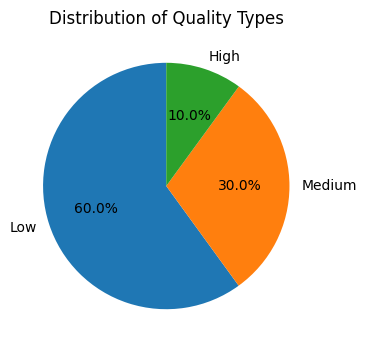

In [12]:
# visualizing Quality Types via pie chart
plt.figure(figsize=(6, 4)) 
plt.title('Distribution of Quality Types') 
plt.pie([low, med, high], labels=['Low', 'Medium', 'High'], autopct='%1.1f%%', startangle=90)
plt.show()

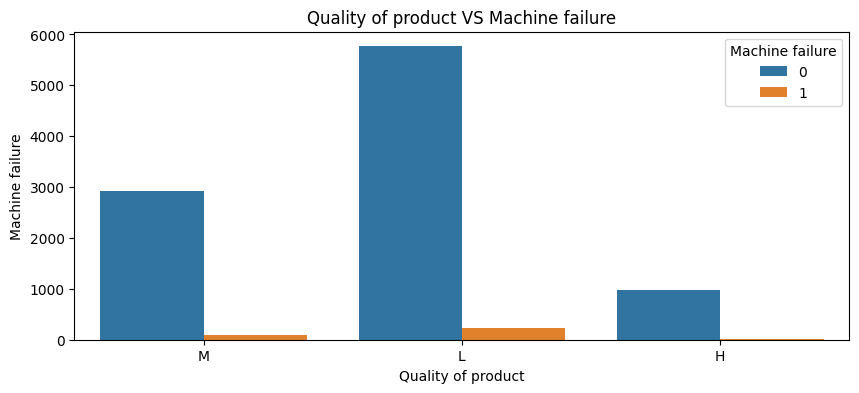

In [13]:
# visualizing Machine failure based on product Quality
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Type', hue='Machine failure')
plt.title('Quality of product VS Machine failure')
plt.xlabel('Quality of product')
plt.ylabel('Machine failure')
plt.show()

In [14]:
# Exploring target variable
zero, one = df['Machine failure'].value_counts()
print(f"Machine failure: {one}\nNo Machine failure: {zero}")

Machine failure: 339
No Machine failure: 9661


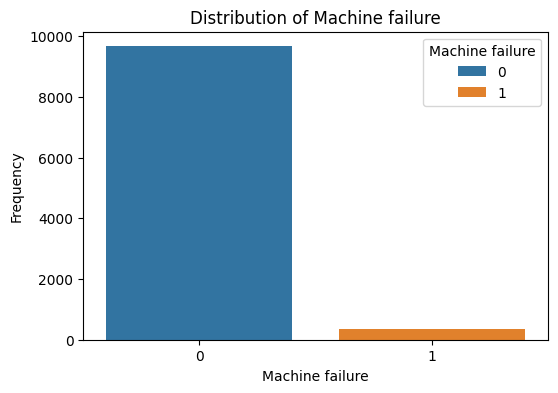

In [15]:
# visualizing target variable(Machine failure)
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=df, hue='Machine failure')
plt.title("Distribution of Machine failure")
plt.xlabel("Machine failure")
plt.ylabel("Frequency")
plt.show()

In [16]:
# checking which failure mode is common
twf = df[df.TWF == 1].value_counts().sum() 
hdf = df[df.HDF == 1].value_counts().sum() 
pwf = df[df.PWF == 1].value_counts().sum() 
osf = df[df.OSF == 1].value_counts().sum() 
rnf = df[df.RNF == 1].value_counts().sum()
print(f"TWF: {twf}\nHDF: {hdf}\nPWF: {pwf}\nOSF: {osf}\nRNF: {rnf}") 

TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 19


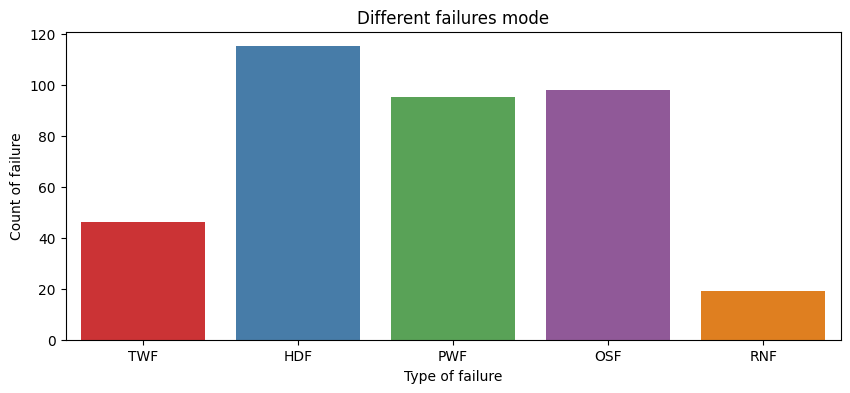

In [17]:
# visualizing the failure mode
df5 = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']]
countf = df5.sum()
plt.figure(figsize=(10, 4))
plt.title('Different failures mode')
plt.xlabel('Type of failure')
plt.ylabel('Count of failure')
sns.barplot(x=countf.index, y=countf.values, errorbar=None, palette="Set1")
plt.show()

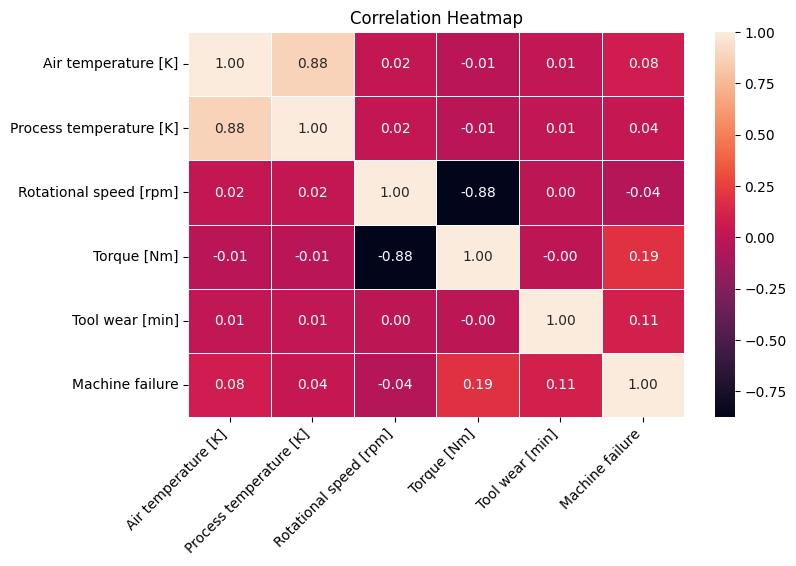

In [18]:
# determining the correlation between the other features and Machine failure via Heatmap
plt.figure(figsize=(8, 5))
heatmap_data = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']]
correlation_matrix = heatmap_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.show()

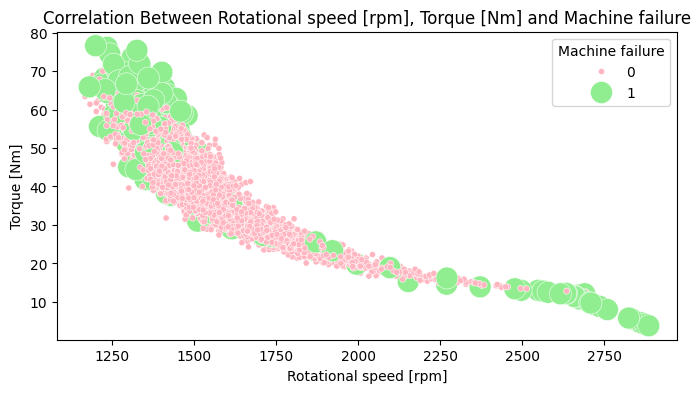

In [19]:
# determining the correlation between the Rotational speed [rpm], Torque [Nm] and Machine failure
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', palette=['lightpink', 'lightgreen'], data=df, size='Machine failure', sizes=(250, 20))
plt.title('Correlation Between Rotational speed [rpm], Torque [Nm] and Machine failure')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.show()

### Data Pre-processing

In [20]:
# dropping some features: UID, Product ID, 
df = df.drop(['UDI','Product ID','TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [21]:
df['Type'].unique()

array(['M', 'L', 'H'], dtype=object)

In [22]:
df['Type'] = df['Type'].map({'L':0,'M':1,'H':2 })

In [23]:
features_name = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type']
X = df[features_name]
y = df['Machine failure']

###  Training and evaluating models

In [24]:
# test and train
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 6) (2000, 6) (8000,) (2000,)


In [25]:
# Random-Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Performance")
print(classification_report(y_test, y_pred_rf))

# XG-Boost
# Ensure feature names are valid strings and do not contain invalid characters for XGBoost
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()
X_train_xgb.columns = [str(col).replace('[','').replace(']','').replace('<','').replace('>','').replace(' ','_') for col in X_train_xgb.columns]
X_test_xgb.columns = X_train_xgb.columns
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_xgb, y_train)
y_pred_xgb = xgb.predict(X_test_xgb)
print("\nXGBoost Performance")
print(classification_report(y_test, y_pred_xgb))


Random Forest Performance
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.86      0.59      0.70        61

    accuracy                           0.98      2000
   macro avg       0.92      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000


XGBoost Performance
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.77      0.61      0.68        61

    accuracy                           0.98      2000
   macro avg       0.88      0.80      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [26]:
# Model Selection
def evaluate_model(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

results = []
results.append(evaluate_model("RandomForest", y_test, y_pred_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))

results_df = pd.DataFrame(results)
print("\nModel Comparison:\n", results_df)

best_model_name = results_df.sort_values("accuracy", ascending=False).iloc[0]["model"]
print(f"\nBest Model Selected: {best_model_name}")


Model Comparison:
           model  accuracy  precision    recall        f1
0  RandomForest    0.9845   0.857143  0.590164  0.699029
1       XGBoost    0.9825   0.770833  0.606557  0.678899

Best Model Selected: RandomForest


In [27]:
# Print train and test accuracy for the best model
if best_model_name == "RandomForest":
    model = rf
else:
    model = xgb
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9845


In [28]:
# Save the best model
if best_model_name == "RandomForest":
    joblib.dump(rf, "best_model.pkl")
else:
    joblib.dump(xgb, "best_model.pkl")

print("Model saved successfully")

Model saved successfully


In [29]:
# Save feature names for Streamlit app
joblib.dump(features_name, "features_name.pkl")
print("Feature names saved as: features_name.pkl")

Feature names saved as: features_name.pkl


In [30]:
# Save model performance metrics
metrics = {
    'accuracy': results_df[results_df['model'] == best_model_name]['accuracy'].iloc[0],
    'precision': results_df[results_df['model'] == best_model_name]['precision'].iloc[0],
    'recall': results_df[results_df['model'] == best_model_name]['recall'].iloc[0],
    'f1': results_df[results_df['model'] == best_model_name]['f1'].iloc[0]
}

joblib.dump(metrics, "metrics.pkl")
print("✅ Model performance metrics saved")

✅ Model performance metrics saved


+ Model training completed successfully!
+ You can now run the Streamlit app: streamlit run app.py